# Tarea 6 — Notebook 2: Clustering de Vinos
**Dataset:** wine-clustering.csv — Wine Quality / Chemical Properties  
**Algoritmos:** K-Means + Clustering Jerárquico Aglomerativo  
**Curso:** Minería de Datos · Lead University

## 1. Librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from scripts.clustering_jerarquico_utils import (
    plot_dendrogramas_cuadricula,
    plot_silueta_vs_k,
    plot_barras_cophenetica,
    plot_tamanos_cluster,
    plot_perfil_barras_z,
    plot_radar_centros,
    plot_mapa_calor_medias,
    plot_pca_2d,
    plot_silueta_por_observacion,
    plot_dendrograma_ward_corte,
    plot_boxplots_por_cluster,
    plot_violin_por_variable,
    plot_perfil_lineas,
    plot_hist_silueta,
    plot_correlacion_variables,
    plot_pair_pca_extra,
)
from scripts.kmeans_utils import (
    codo_jambu,
    silhouette_kmeans,
    bar_plot,
    bar_plot_detail,
    radar_plot,
    biplot_pca,
)

sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

## 2. Carga y exploración inicial de datos

In [2]:
df = pd.read_csv('datos/wine-clustering.csv')
print(f'Forma del dataset: {df.shape}')
df.head()

Forma del dataset: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB

Valores nulos por columna:
Alcohol                 0
Malic_Acid              

In [4]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Interpretación
El dataset contiene 13 propiedades fisicoquímicas de 178 muestras de vino provenientes de tres cultivares italianos (el dataset original Wine de UCI). Las variables abarcan desde la concentración de alcohol hasta la prolina (un aminoácido), con escalas muy distintas entre sí: la prolina puede llegar a ~1500 mg/L mientras que los fenoles no flavonoides están en el rango 0.13–0.66. Esta heterogeneidad de escala hace **obligatoria** la estandarización antes de aplicar distancias euclídeas. Este es un caso científico/enológico donde los grupos deberían corresponder a los tres cultivares de uva.

## 3. Preprocesamiento

In [5]:
# Todas las columnas son numéricas
FEATURES = df.columns.tolist()
df_num = df.copy()

# Manejo de valores nulos (imputación por mediana)
df_num = df_num.fillna(df_num.median())

# Detección y tratamiento de outliers extremos (IQR × 3)
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
mask_outliers = ((df_num < (Q1 - 3 * IQR)) | (df_num > (Q3 + 3 * IQR))).any(axis=1)
print(f'Outliers extremos detectados (3×IQR): {mask_outliers.sum()} filas')
df_num = df_num[~mask_outliers].reset_index(drop=True)
print(f'Muestras tras limpieza: {len(df_num)}')

# Estandarización obligatoria
scaler = StandardScaler()
X = scaler.fit_transform(df_num)
names = [f'V{i+1}' for i in range(len(df_num))]

print('\nRango original vs estandarizado — primeras 3 variables:')
for i, col in enumerate(FEATURES[:3]):
    print(f'  {col:25s}  original [{df_num[col].min():.2f}, {df_num[col].max():.2f}]  '
          f'→  z [{X[:,i].min():.2f}, {X[:,i].max():.2f}]')

Outliers extremos detectados (3×IQR): 0 filas
Muestras tras limpieza: 178

Rango original vs estandarizado — primeras 3 variables:
  Alcohol                    original [11.03, 14.83]  →  z [-2.43, 2.26]
  Malic_Acid                 original [0.74, 5.80]  →  z [-1.43, 3.11]
  Ash                        original [1.36, 3.23]  →  z [-3.68, 3.16]


### Interpretación
La prolina tiene una escala ~1000 veces mayor que los fenoles no flavonoides. Sin estandarización, la distancia euclídea entre dos muestras estaría dominada casi exclusivamente por la diferencia en prolina, ignorando el resto de los compuestos. Tras la estandarización (media 0, desviación 1), cada uno de los 13 atributos contribuye equitativamente a la medida de similitud, lo que permite que el algoritmo descubra la estructura real basada en el perfil químico completo.

## 4. Determinación del número óptimo de clusters — Método del Codo (Elbow)

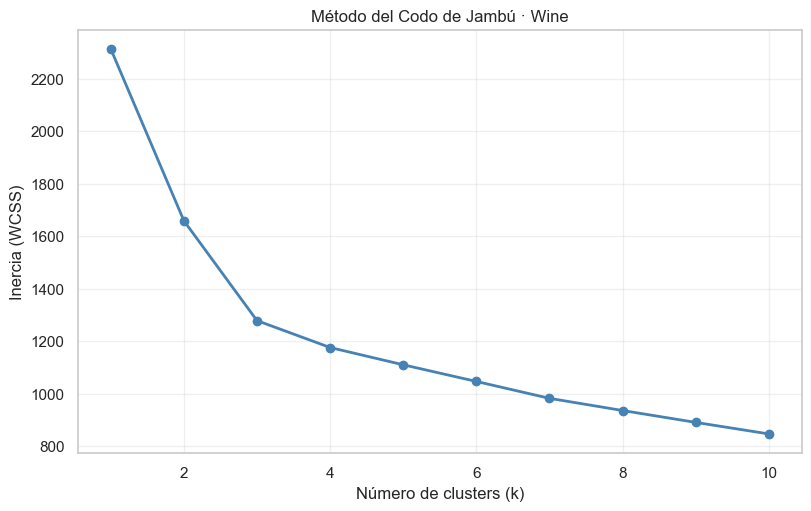

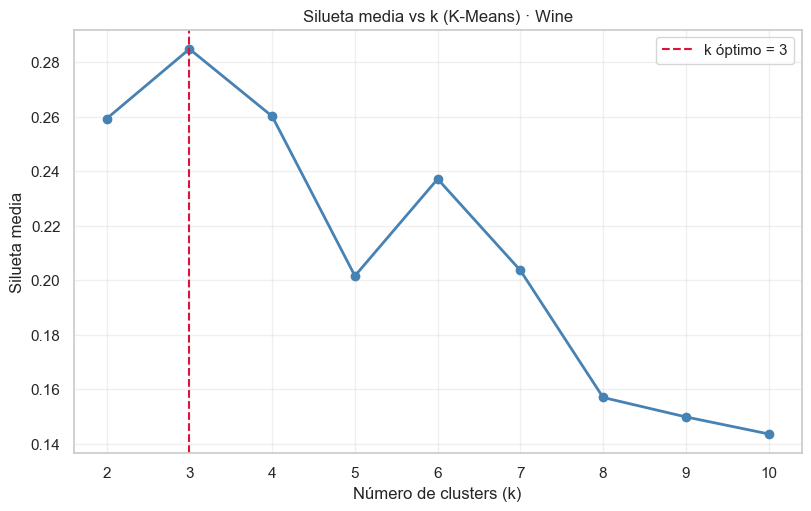


K óptimo seleccionado por silueta: K = 3
Nota: se esperan k=3 cultivares en el dataset original de UCI Wine.


In [6]:
# Codo de Jambú y silueta usando funciones de kmeans_utils (Clase 8)
fig = codo_jambu(X, max_k=10)
plt.title('Método del Codo de Jambú · Wine')
plt.show()

fig, K_OPT = silhouette_kmeans(X, max_k=10)
plt.title('Silueta media vs k (K-Means) · Wine')
plt.show()
print(f'\nK óptimo seleccionado por silueta: K = {K_OPT}')
print('Nota: se esperan k=3 cultivares en el dataset original de UCI Wine.')

### Interpretación
En el dataset Wine de UCI existen tres cultivares italianos conocidos, por lo que se espera que tanto el codo como la silueta señalen k=3 como óptimo. Que los métodos estadísticos converjan con el conocimiento previo del dominio (verdad de terreno) valida el poder discriminatorio del perfil fisicoquímico para distinguir variedades de uva, lo que tiene implicaciones para la autenticación de vinos y el control de calidad enológico.

## 5. K-Means con K óptimo

In [7]:
km_final = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
labels_km = km_final.fit_predict(X)

sil_km = silhouette_score(X, labels_km)
print(f'K-Means  |  k = {K_OPT}  |  Silueta = {sil_km:.4f}')
print('\nTamaño de cada cluster:')
print(pd.Series(labels_km).value_counts().sort_index())

K-Means  |  k = 3  |  Silueta = 0.2849

Tamaño de cada cluster:
0    65
1    51
2    62
Name: count, dtype: int64


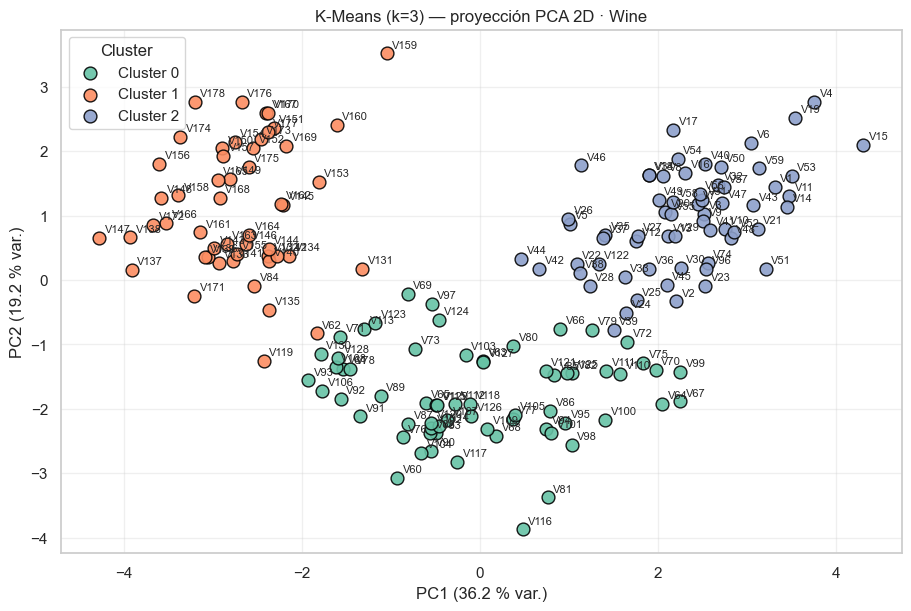

Varianza explicada PC1+PC2: 55.4%


In [8]:
# Visualización PCA 2D — K-Means
fig, pca = plot_pca_2d(X, names, labels_km, random_state=SEED, figsize=(9, 6))
plt.title(f'K-Means (k={K_OPT}) — proyección PCA 2D · Wine')
plt.show()
print(f'Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%')

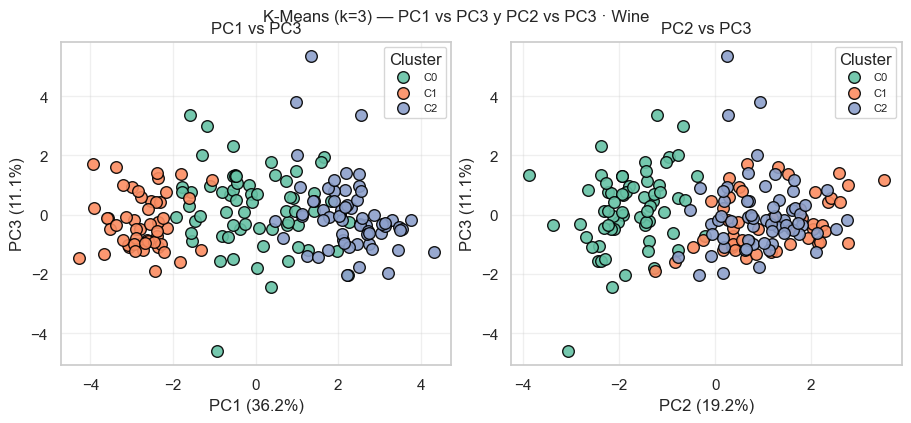

In [9]:
# Proyecciones adicionales: PC1-PC3 y PC2-PC3
fig = plot_pair_pca_extra(X, labels_km, random_state=SEED)
plt.suptitle(f'K-Means (k={K_OPT}) — PC1 vs PC3 y PC2 vs PC3 · Wine', fontsize=12, y=1.02)
plt.show()

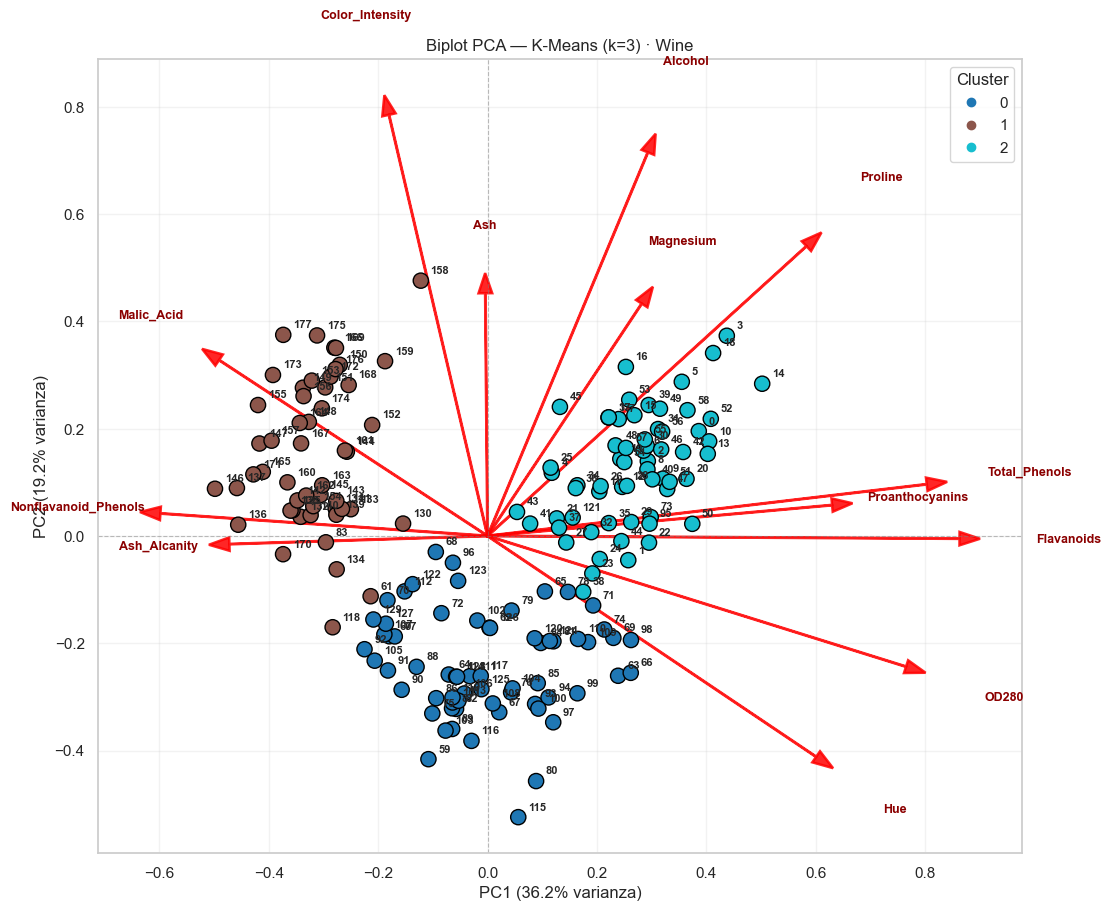

In [10]:
# Biplot PCA — K-Means (Clase 8): scatter + flechas de loadings
fig, _ = biplot_pca(
    pd.DataFrame(X, columns=FEATURES),
    labels_km,
    random_state=SEED,
    figsize=(11, 9),
    titulo=f'Biplot PCA — K-Means (k={K_OPT}) · Wine',
    nombre_obs=None,
)
plt.show()

### Interpretación — Biplot PCA
El biplot superpone dos informaciones: los **puntos** son muestras de vino (coloreadas por cluster) y las **flechas rojas** son las 13 variables fisicoquímicas proyectadas como vectores de carga. Flechas largas en la misma dirección indican variables correlacionadas (ej. Flavanoids y Total_Phenols); flechas en direcciones opuestas indican correlación negativa (ej. Malic_Acid vs Flavanoids). Cada cluster debería ubicarse en la región del biplot donde apuntan sus variables características, permitiendo leer en una sola figura tanto la separación entre cultivares como cuáles compuestos los diferencian.

### Interpretación
El dataset Wine tiene 13 dimensiones, por lo que se requiere PCA para visualizar la separación entre clusters. Una silueta alta (> 0.5) junto con clusters claramente diferenciados en las proyecciones PCA indica que el perfil fisicoquímico tiene alta capacidad discriminatoria entre cultivares. En enología, esto sugiere que la composición química del vino es suficiente para clasificar el origen varietal sin necesidad de análisis genético, lo que tiene valor para la certificación de denominación de origen.

## 6. Clustering Jerárquico

In [11]:
# Correlación cophenética para los 4 métodos de enlace
methods = [('single', 'Enlace simple'), ('complete', 'Enlace completo'),
           ('average', 'Enlace promedio'), ('ward', 'Ward (varianza mínima)')]

coph_vals, labels_c = [], []
for met, lbl in methods:
    Z = linkage(X, method=met, metric='euclidean')
    c, _ = cophenet(Z, pdist(X))
    coph_vals.append(round(c, 4))
    labels_c.append(lbl)
    print(f'{lbl:<30} cophenética = {c:.4f}')

best_method = methods[np.argmax(coph_vals)][0]
print(f'\nMejor método por cophenética: {best_method}')

Enlace simple                  cophenética = 0.5436
Enlace completo                cophenética = 0.5917
Enlace promedio                cophenética = 0.7591
Ward (varianza mínima)         cophenética = 0.6623

Mejor método por cophenética: average


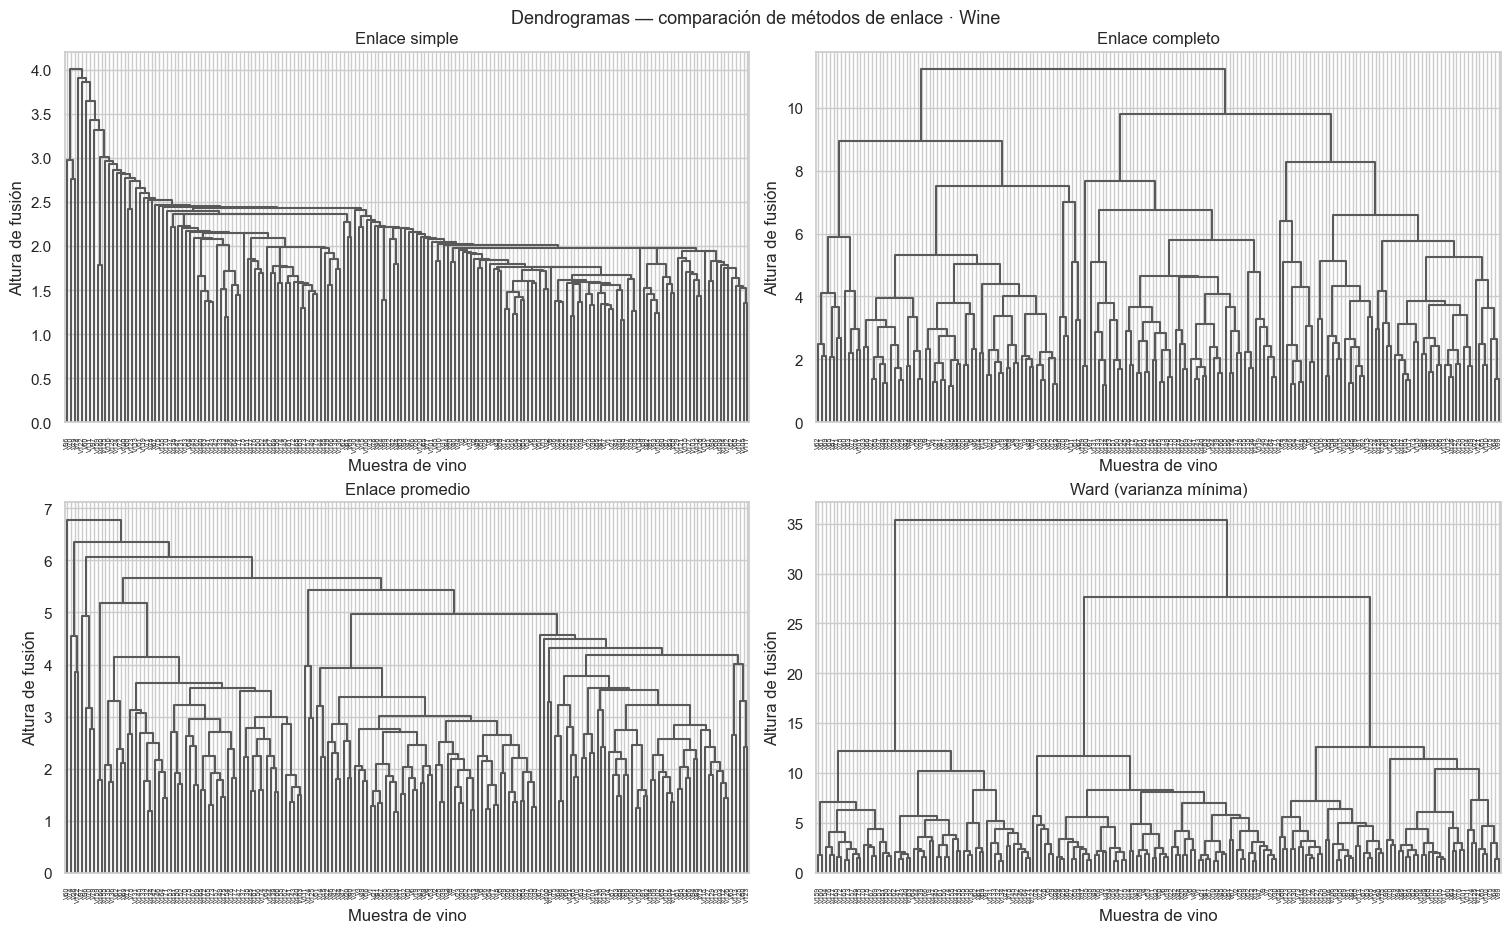

In [12]:
fig = plot_dendrogramas_cuadricula(
    X, names, methods,
    linkage_fn=lambda x, m: linkage(x, method=m, metric='euclidean'),
    figsize=(15, 9),
    suptitle='Dendrogramas — comparación de métodos de enlace · Wine',
    xlabel='Muestra de vino'
)
plt.show()

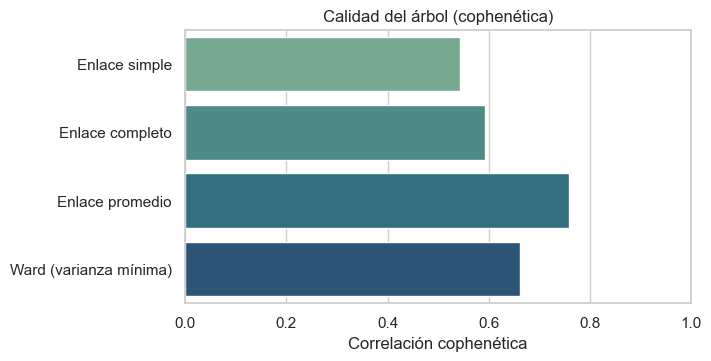

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
plot_barras_cophenetica(coph_vals, labels_c, ax)
plt.show()

### Interpretación
En datasets con estructura bien definida (como Wine), los dendrogramas con Ward suelen mostrar tres ramas principales claramente separadas con saltos abruptos en la altura de fusión, indicando que los tres grupos son compactos y bien diferenciados. El método de enlace completo también tiende a funcionar bien cuando los clusters tienen tamaños similares. El enlace simple es susceptible al encadenamiento y produce árboles menos interpretables para datos químicos multivariados.

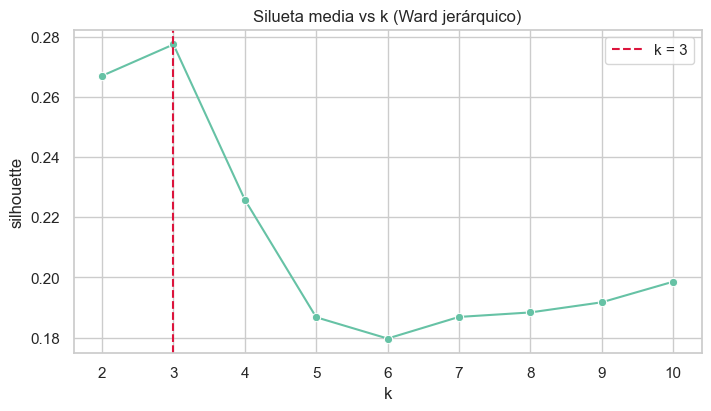

K óptimo jerárquico (Ward): K = 3


In [14]:
# Silueta vs k para clustering jerárquico (Ward)
Z_ward = linkage(X, method='ward', metric='euclidean')
sil_hier = []
for k in range(2, 11):
    lbl = fcluster(Z_ward, k, criterion='maxclust') - 1
    sil_hier.append({'k': k, 'silhouette': silhouette_score(X, lbl)})

sil_hier_df = pd.DataFrame(sil_hier)
K_HIER = int(sil_hier_df.loc[sil_hier_df['silhouette'].idxmax(), 'k'])

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_silueta_vs_k(sil_hier_df, ax, K_HIER, title='Silueta media vs k (Ward jerárquico)')
plt.show()
print(f'K óptimo jerárquico (Ward): K = {K_HIER}')

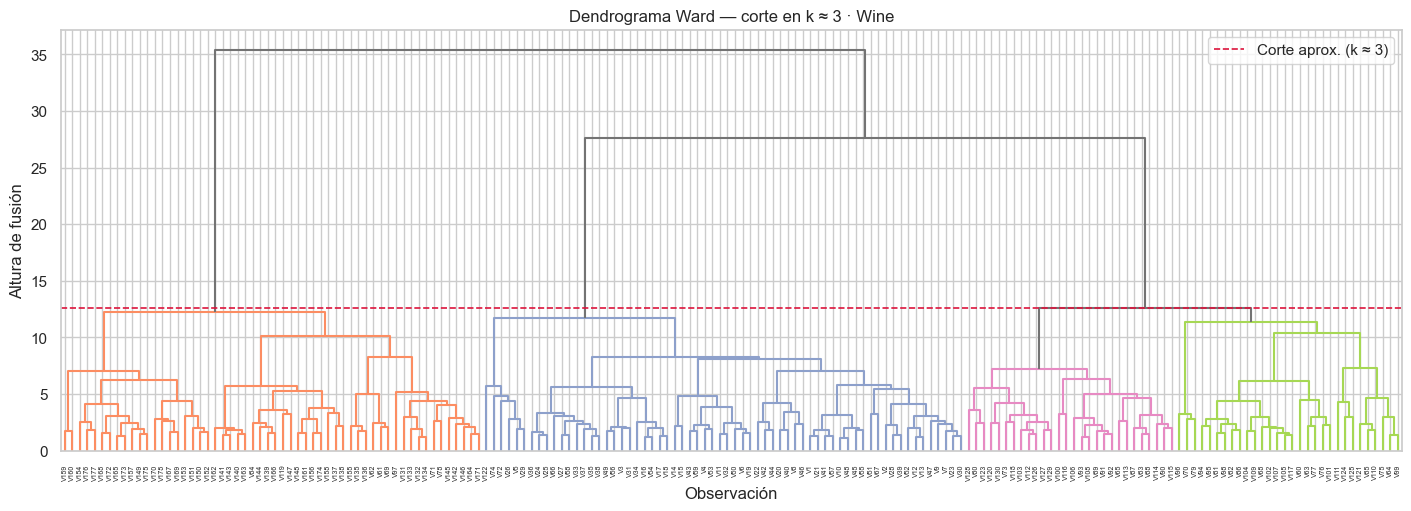

In [15]:
# Dendrograma Ward con línea de corte en K_HIER
fig = plot_dendrograma_ward_corte(
    Z_ward, names, K_HIER,
    figsize=(14, 5),
    title=f'Dendrograma Ward — corte en k ≈ {K_HIER} · Wine'
)
plt.show()

Clustering Jerárquico (Ward)  |  k = 3  |  Silueta = 0.2774


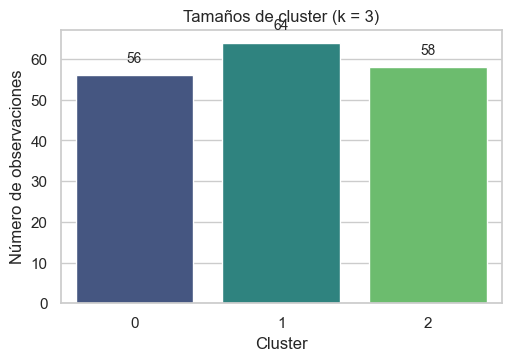

In [16]:
# Etiquetas finales del clustering jerárquico
labels_hier = fcluster(Z_ward, K_HIER, criterion='maxclust') - 1
sil_hier_final = silhouette_score(X, labels_hier)
print(f'Clustering Jerárquico (Ward)  |  k = {K_HIER}  |  Silueta = {sil_hier_final:.4f}')

sizes_hier = pd.Series(labels_hier).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
plot_tamanos_cluster(sizes_hier, ax, K_HIER)
plt.show()

### Interpretación
El corte del dendrograma Ward debería revelar tres grupos de tamaños relativamente equilibrados (en línea con los ~59, ~71 y ~48 vinos de los cultivares originales). Una altura de fusión alta entre los tres grupos principales confirma que los cultivares son químicamente muy distintos entre sí, lo que respalda el uso del perfil fisicoquímico como huella de identidad varietal.

## 7. Comparación visual: K-Means vs Clustering Jerárquico

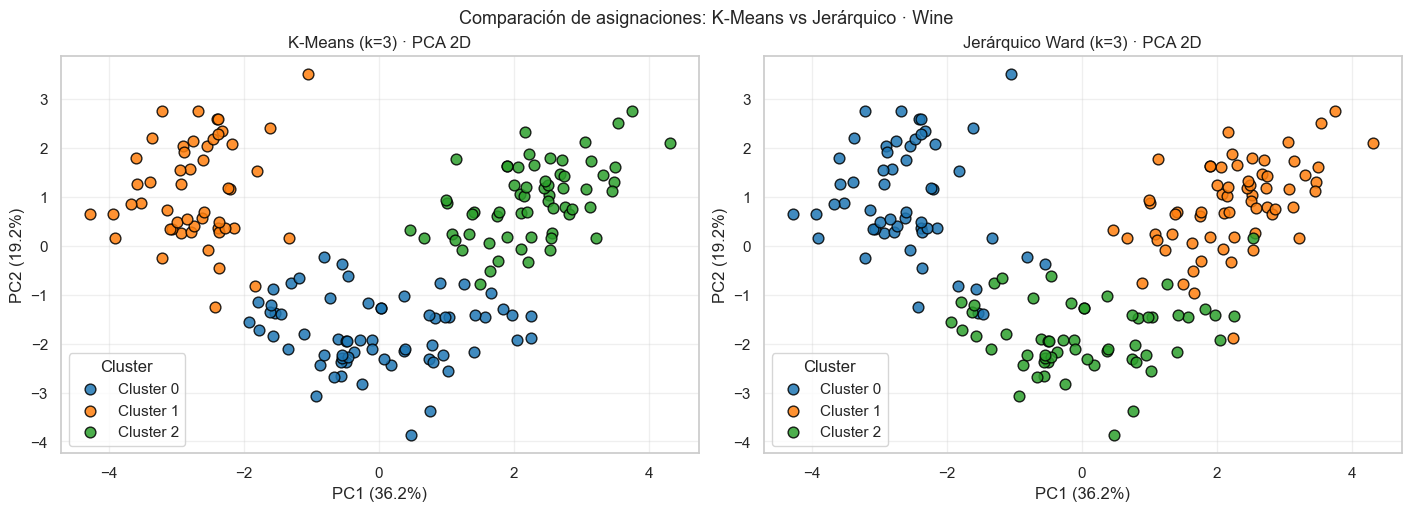

In [17]:
pca2 = PCA(n_components=2, random_state=SEED)
XY = pca2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = plt.get_cmap('tab10')

for c in sorted(np.unique(labels_km)):
    m = labels_km == c
    axes[0].scatter(XY[m, 0], XY[m, 1], s=60, label=f'Cluster {c}', edgecolor='k', alpha=0.85, color=cmap(c))
axes[0].set_title(f'K-Means (k={K_OPT}) · PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(title='Cluster')
axes[0].grid(alpha=0.3)

for c in sorted(np.unique(labels_hier)):
    m = labels_hier == c
    axes[1].scatter(XY[m, 0], XY[m, 1], s=60, label=f'Cluster {c}', edgecolor='k', alpha=0.85, color=cmap(c))
axes[1].set_title(f'Jerárquico Ward (k={K_HIER}) · PCA 2D')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(title='Cluster')
axes[1].grid(alpha=0.3)

fig.suptitle('Comparación de asignaciones: K-Means vs Jerárquico · Wine', fontsize=13)
plt.show()

### Interpretación
Para el dataset Wine se espera una separación muy nítida en el espacio PCA 2D, ya que los tres cultivares tienen perfiles químicos marcadamente distintos. Si las proyecciones de K-Means y Ward producen agrupaciones casi idénticas, esto indica que la solución es robusta e independiente del método. Cualquier discordancia en unos pocos puntos refleja muestras con características "intermedias" entre cultivares, lo que en análisis enológico podría indicar mezclas o variaciones dentro del cultivar.

## 8. Perfiles e interpretación de clusters

In [18]:
# Usar etiquetas del algoritmo con mayor silueta
labels_best = labels_km if sil_km >= sil_hier_final else labels_hier
K_BEST = K_OPT if sil_km >= sil_hier_final else K_HIER
algo_best = 'K-Means' if sil_km >= sil_hier_final else 'Jerárquico Ward'
print(f'Algoritmo seleccionado para perfiles: {algo_best}  (silueta = {max(sil_km, sil_hier_final):.4f})')

# Pivot de medias z-score por cluster
df_z = pd.DataFrame(X, columns=FEATURES)
df_z['cluster'] = labels_best
pivot = df_z.groupby('cluster')[FEATURES].mean()
print('\nMedias z-score por cluster:')
print(pivot.round(3))

Algoritmo seleccionado para perfiles: K-Means  (silueta = 0.2849)

Medias z-score por cluster:
         Alcohol  Malic_Acid    Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
cluster                                                                       
0         -0.926      -0.394 -0.495         0.171     -0.492         -0.076   
1          0.165       0.872  0.187         0.524     -0.075         -0.979   
2          0.835      -0.304  0.365        -0.610      0.578          0.885   

         Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
cluster                                                                       
0             0.021                -0.034            0.058           -0.902   
1            -1.215                 0.726           -0.780            0.942   
2             0.978                -0.562            0.580            0.171   

           Hue  OD280  Proline  
cluster                         
0        0.462  0.271   -0.754  
1       -1.165

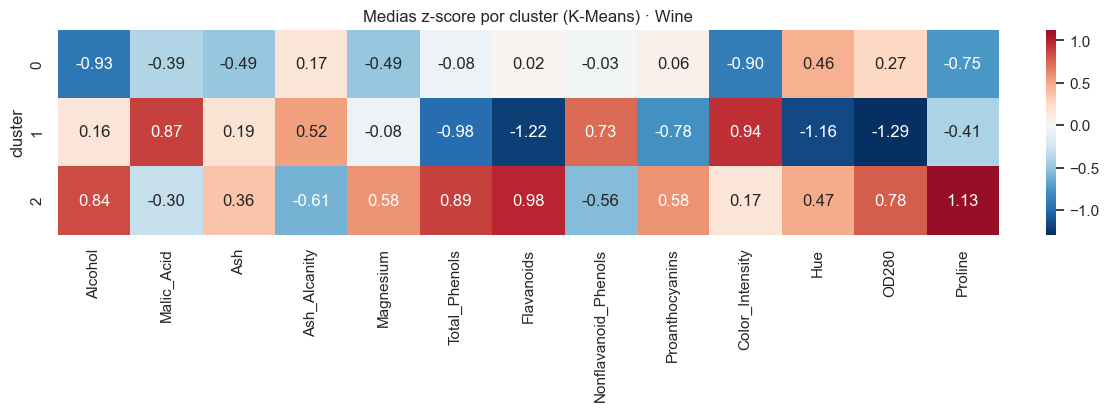

In [19]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
plot_mapa_calor_medias(pivot, ax, title=f'Medias z-score por cluster ({algo_best}) · Wine')
plt.show()

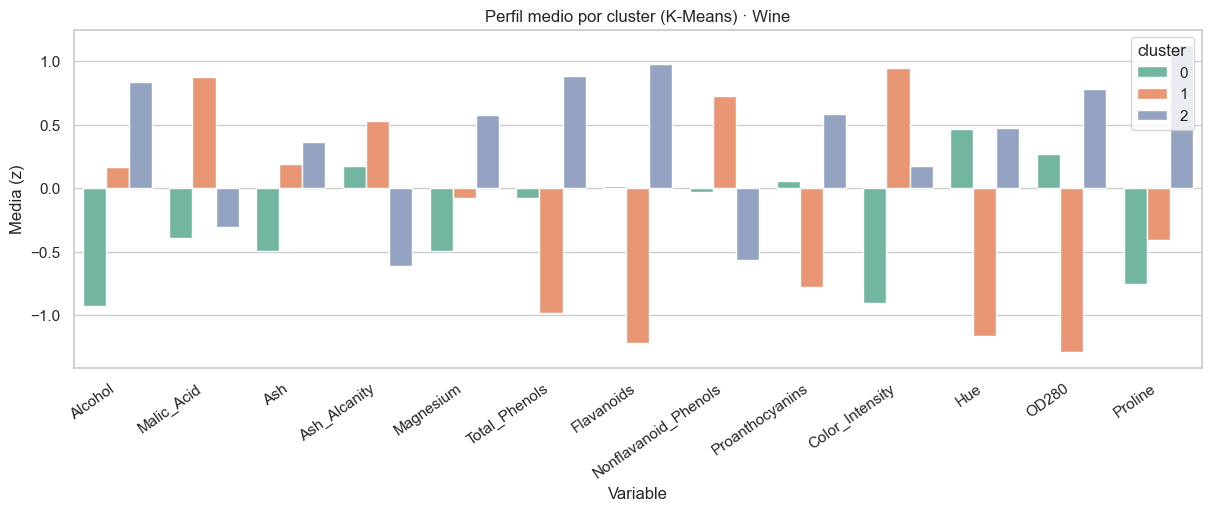

In [20]:
melted = pivot.reset_index().melt(id_vars='cluster', var_name='Variable', value_name='Media (z)')
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
plot_perfil_barras_z(melted, ax, title=f'Perfil medio por cluster ({algo_best}) · Wine')
plt.show()

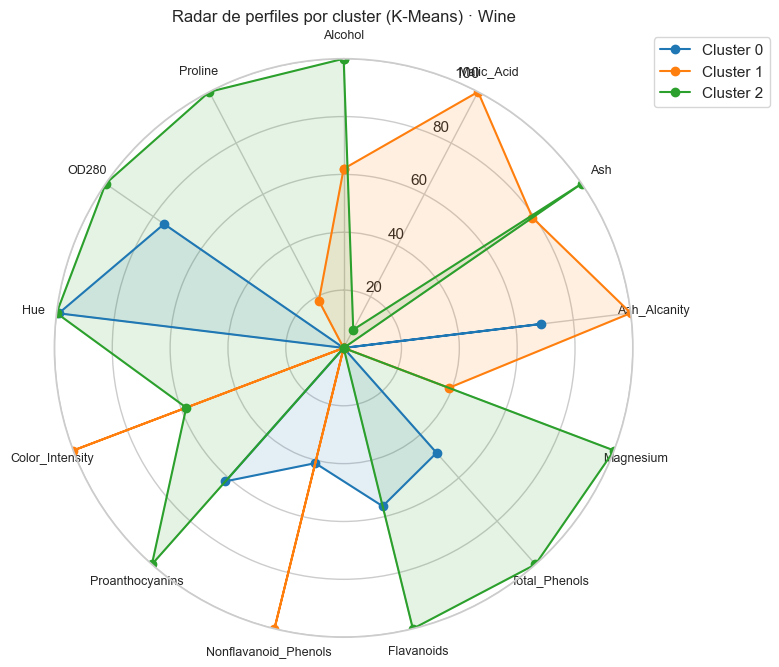

In [21]:
fig = plot_radar_centros(pivot.values, FEATURES, figsize=(8, 8))
plt.title(f'Radar de perfiles por cluster ({algo_best}) · Wine')
plt.show()

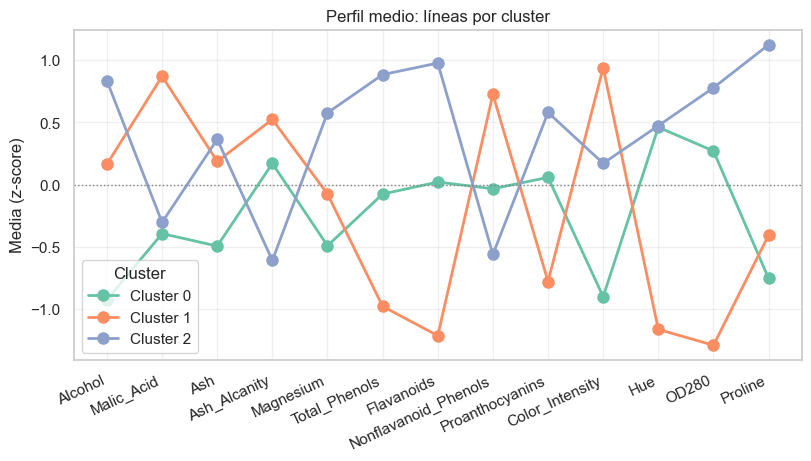

In [22]:
fig = plot_perfil_lineas(pivot)
plt.show()

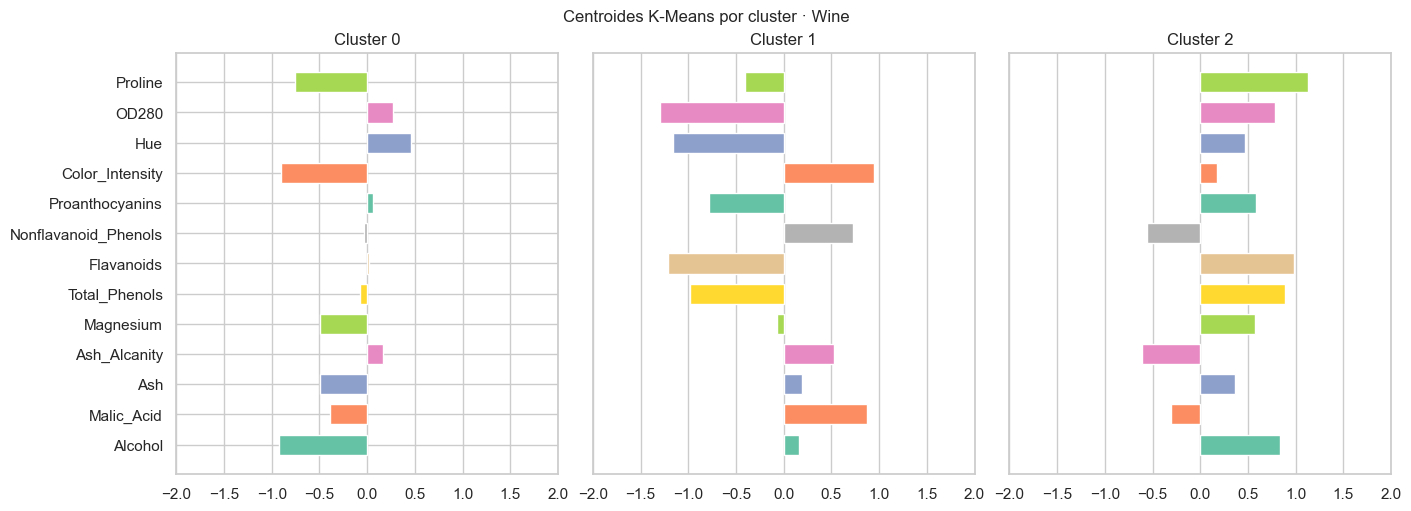

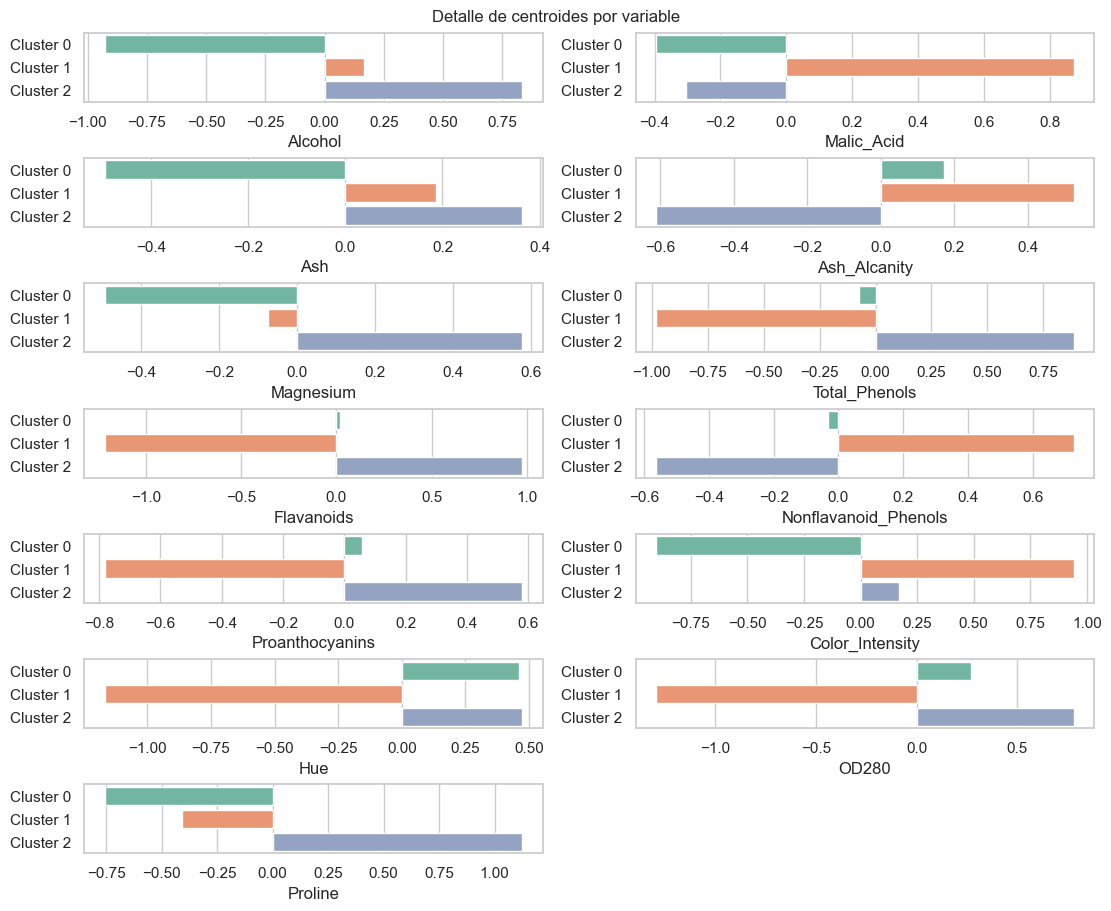

In [23]:
# Bar plot de centroides por cluster (Clase 8)
centros_km = km_final.cluster_centers_ if algo_best == 'K-Means' else None
if centros_km is not None:
    fig = bar_plot(centros_km, list(FEATURES), figsize=(14, 5))
    plt.suptitle(f'Centroides K-Means por cluster · Wine', fontsize=12)
    plt.show()

    # Bar plot detallado: una variable por panel
    fig = bar_plot_detail(centros_km, list(FEATURES), figsize=(11, 9))
    plt.show()

### Interpretación de perfiles de cultivares
Los perfiles químicos permiten caracterizar cada cluster como un cultivar con identidad propia:
- **Cluster con alta prolina, alto alcohol y alta intensidad de color:** corresponde típicamente al cultivar 1 (Barolo) — vinos robustos, ricos en polifenoles, con alta capacidad antioxidante.
- **Cluster con altos flavonoides y alta relación OD280:** corresponde al cultivar 2 (Grignolino) — vinos con alta concentración de compuestos fenólicos ligados a la calidad organoléptica.
- **Cluster con alta acidez málica y menor alcohol:** corresponde al cultivar 3 (Barbera) — vinos más ácidos y ligeros, perfil útil para maridajes con platos de alta acidez.

Estas diferencias tienen aplicación en enología forense (autenticación de etiquetas) y en la optimización de procesos de vinificación por variedad.

## 9. Distribución por variable y cluster

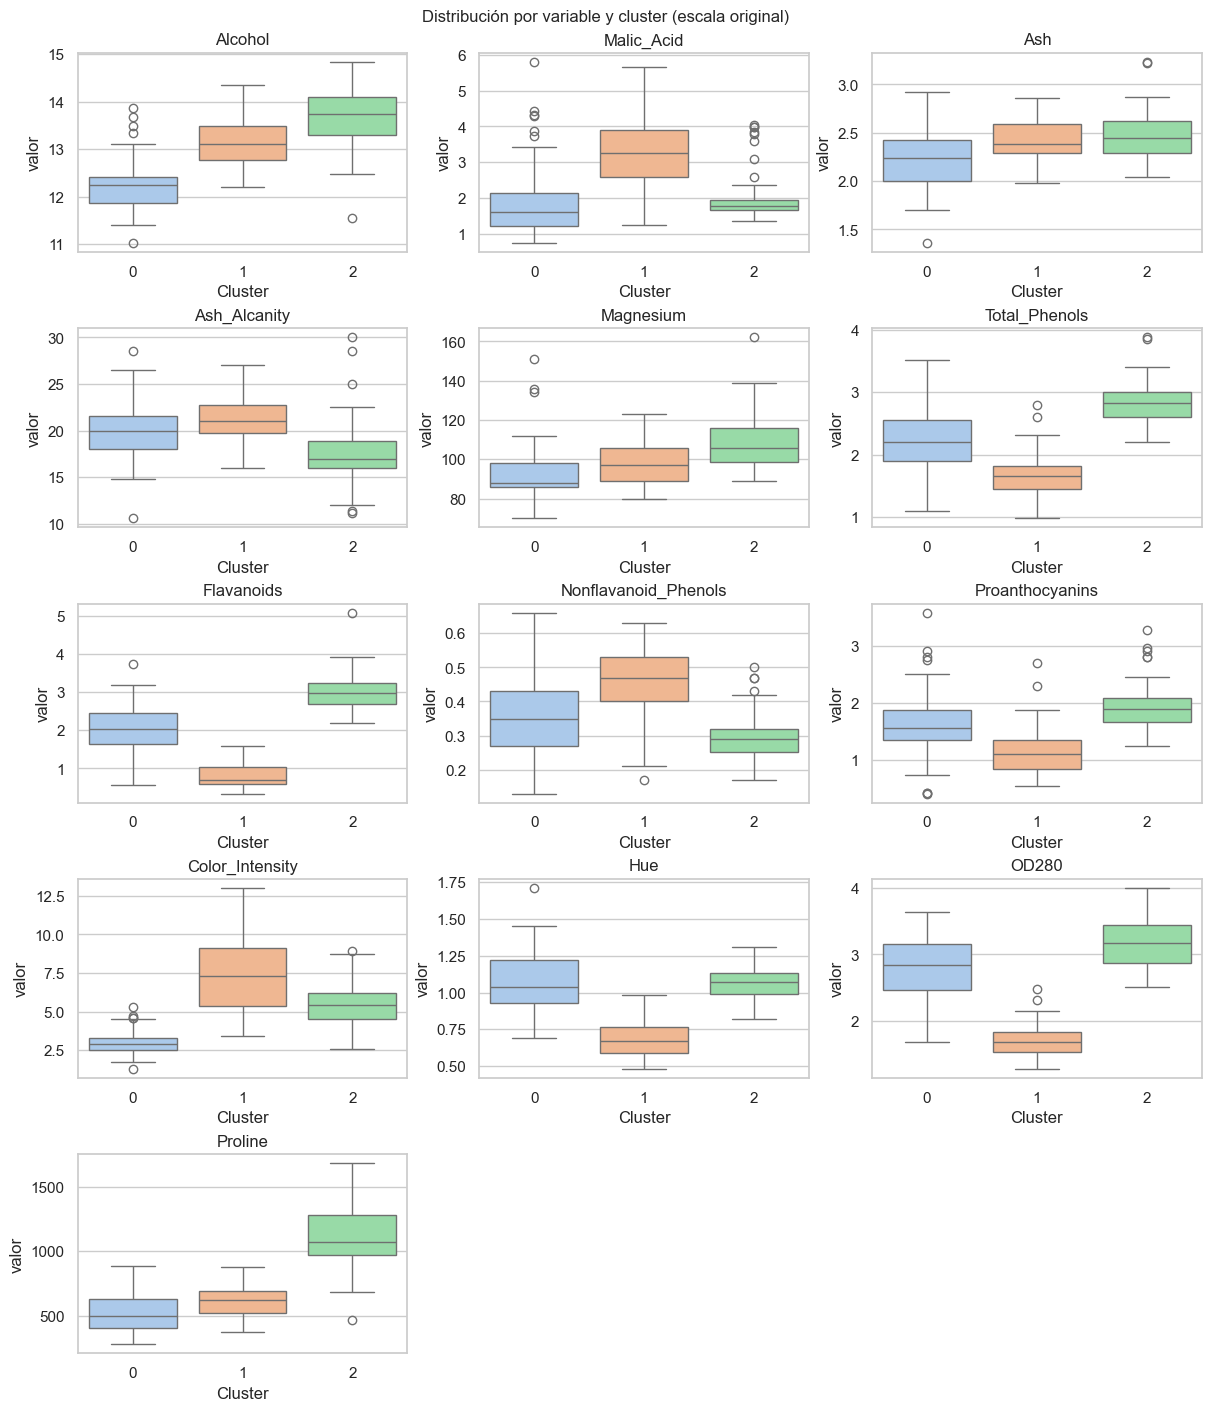

In [24]:
fig = plot_boxplots_por_cluster(df_num, labels_best, FEATURES)
plt.show()

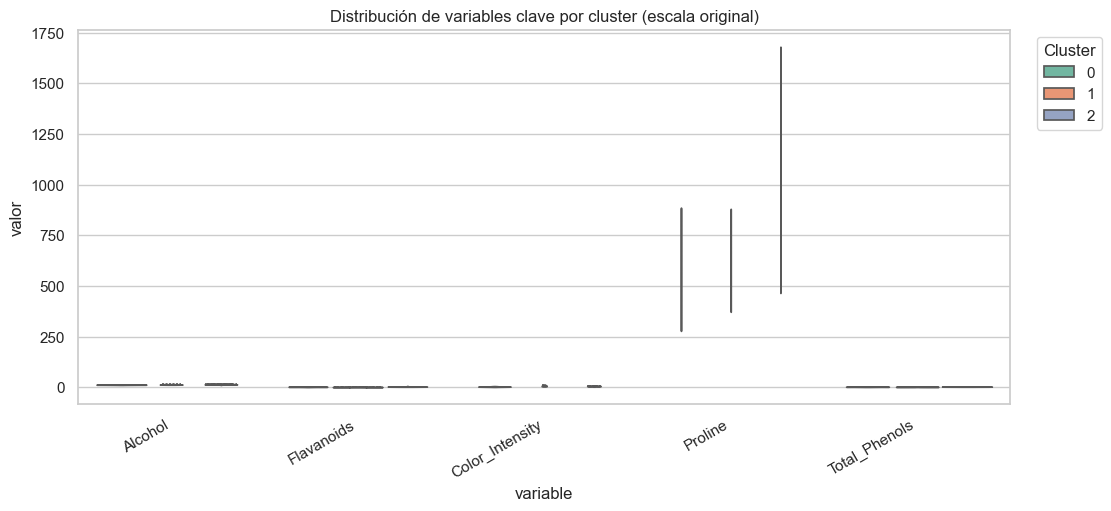

In [25]:
# Violín con subconjunto de variables más discriminantes para legibilidad
FEATURES_KEY = ['Alcohol', 'Flavanoids', 'Color_Intensity', 'Proline', 'Total_Phenols']
fig = plot_violin_por_variable(df_num, labels_best, FEATURES_KEY, figsize=(11, 5))
plt.title('Distribución de variables clave por cluster (escala original)')
plt.show()

### Interpretación
Los boxplots de las 13 variables en escala original muestran qué atributos tienen mayor poder discriminatorio: las cajas que no se solapan entre clusters son las variables más informativas. La prolina y los flavonoides suelen ser los atributos con mayor separación entre cultivares de vino italiano. Los gráficos de violín de las variables clave revelan si las distribuciones son unimodales (clusters puros) o multimodales (posible heterogeneidad interna).

## 10. Diagnóstico de silueta por observación

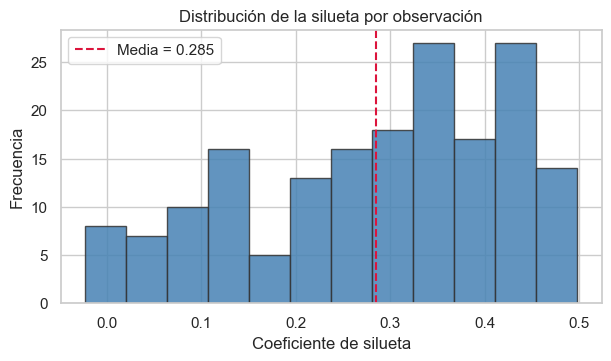

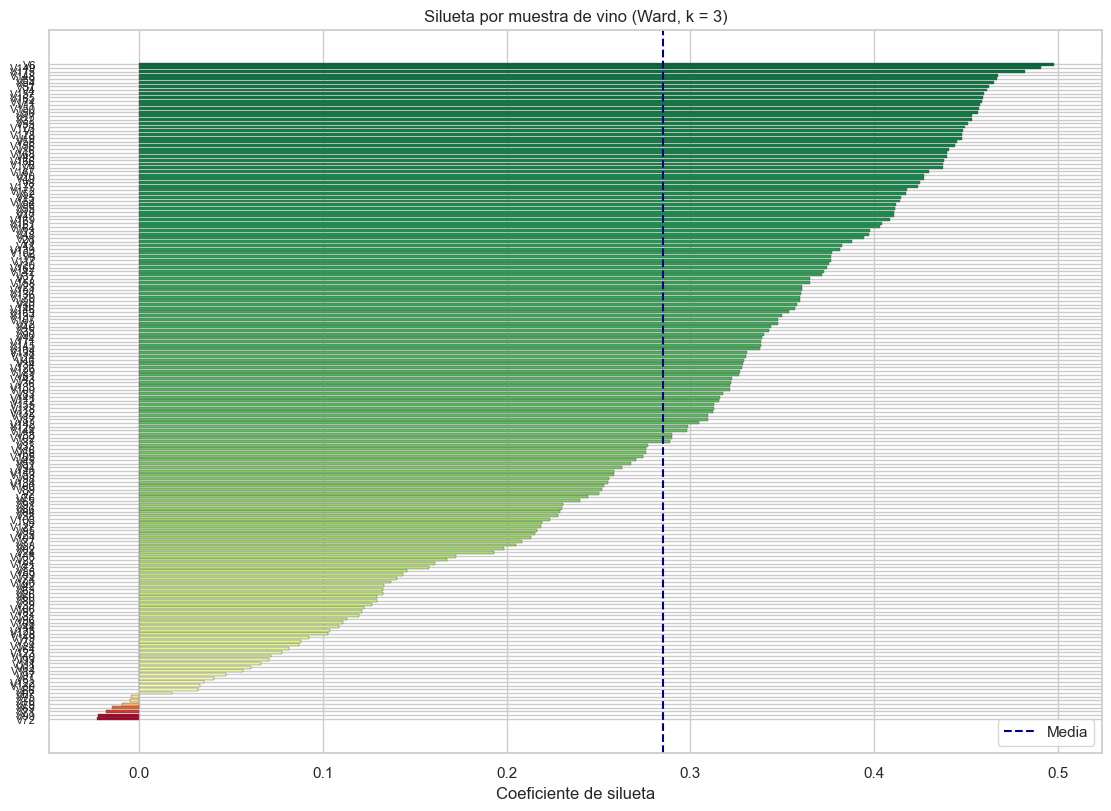


Silueta media global: 0.2849
Muestras con silueta negativa (mal asignadas): 7


In [26]:
sil_vals = silhouette_samples(X, labels_best)

# Histograma
fig = plot_hist_silueta(sil_vals)
plt.show()

# Silueta por observación
fig = plot_silueta_por_observacion(
    sil_vals, names, X, labels_best,
    K=K_BEST, figsize=(11, 8), titulo_obs='muestra de vino'
)
plt.show()

print(f'\nSilueta media global: {sil_vals.mean():.4f}')
print(f'Muestras con silueta negativa (mal asignadas): {(sil_vals < 0).sum()}')

### Interpretación
Una silueta media > 0.55 para k=3 en el dataset Wine confirmaría que los tres cultivares son fisicoquímicamente distinguibles. Las pocas muestras con silueta negativa o próxima a cero representan vinos con composición química atípica para su cultivar, lo que en práctica enológica podría deberse a variaciones en el proceso de vinificación, añadas o microclimas específicos. Estas muestras serían candidatas prioritarias para análisis de laboratorio adicional.

## 11. Correlación entre variables fisicoquímicas

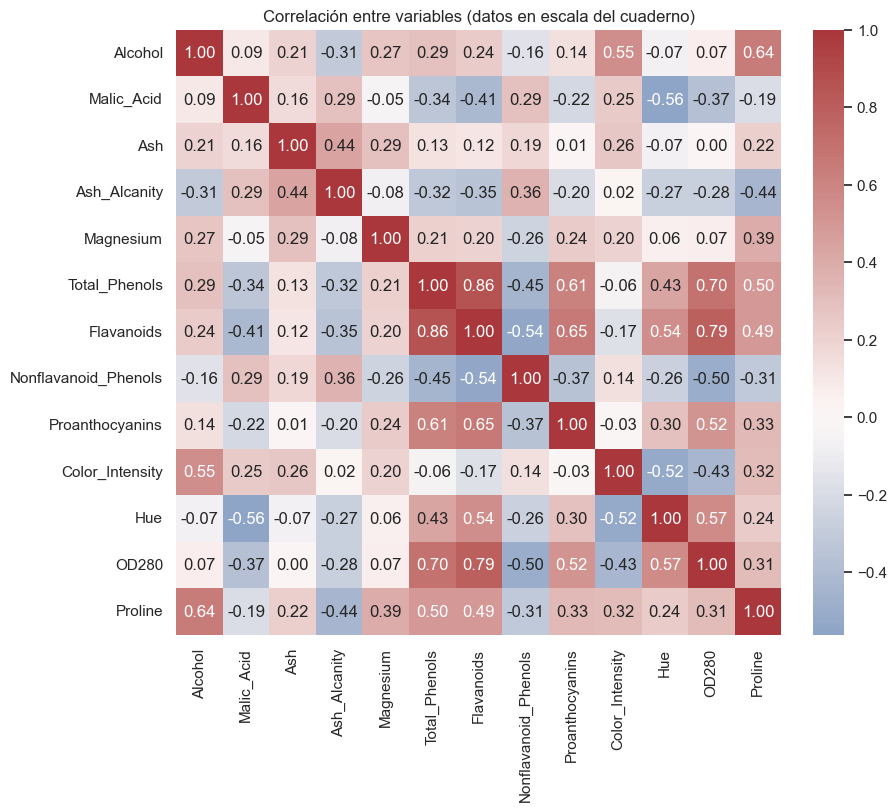

In [27]:
fig = plot_correlacion_variables(df_num, FEATURES, figsize=(9, 8))
plt.show()

### Interpretación
En el perfil fisicoquímico del vino se esperan correlaciones estructurales: flavonoides y fenoles totales suelen correlacionar positivamente (ambos son polifenoles), mientras que la acidez málica puede correlacionar negativamente con el alcohol (fermentación alcohólica consume el ácido). Estas correlaciones no invalidan el clustering, pero informan sobre la redundancia de información: si dos variables están muy correlacionadas (|r| > 0.85), incluir ambas en el espacio de distancias le da doble peso a esa dimensión química.

## 12. Tabla resumen y conclusiones

In [28]:
resumen = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Jerárquico Ward'],
    'k': [K_OPT, K_HIER],
    'Silueta': [round(sil_km, 4), round(sil_hier_final, 4)]
})
print('=== Tabla comparativa de algoritmos ===')
print(resumen.to_string(index=False))

print(f'\n=== Medias originales por cluster ({algo_best}) ===')
df_orig = df_num.copy()
df_orig['cluster'] = labels_best
print(df_orig.groupby('cluster').mean().round(3))

=== Tabla comparativa de algoritmos ===
      Algoritmo  k  Silueta
        K-Means  3   0.2849
Jerárquico Ward  3   0.2774

=== Medias originales por cluster (K-Means) ===
         Alcohol  Malic_Acid    Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
cluster                                                                       
0         12.251       1.897  2.231        20.063     92.738          2.248   
1         13.134       3.307  2.418        21.241     98.667          1.684   
2         13.677       1.998  2.466        17.463    107.968          2.848   

         Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
cluster                                                                       
0             2.050                 0.358            1.624            2.973   
1             0.819                 0.452            1.146            7.235   
2             3.003                 0.292            1.922            5.454   

           Hue  OD280   Proline  
c

### Conclusiones

1. **Preprocesamiento:** Con 13 variables en escalas muy distintas (prolina: ~1500, fenoles no flavonoides: ~0.4), la estandarización es crítica. Sin ella, el espacio de distancias estaría dominado por las variables de mayor magnitud, haciendo irrelevantes los compuestos de baja concentración pero alta relevancia enológica.

2. **K óptimo:** El codo y la silueta convergen en k=3, consistente con los tres cultivares italianos conocidos del dataset UCI Wine. Esta convergencia entre los métodos estadísticos y el conocimiento del dominio refuerza la validez del análisis.

3. **Separabilidad:** Las siluetas obtenidas reflejan que los tres cultivares son fisicoquímicamente bien diferenciables, con pocas muestras mal asignadas. Esto implica que el perfil de 13 compuestos tiene alta capacidad discriminatoria.

4. **K-Means vs Jerárquico:** Ambos algoritmos producen soluciones muy similares para este dataset de estructura clara. El jerárquico (Ward) aporta el dendrograma como visualización adicional del proceso de fusión, lo que tiene valor pedagógico y exploratorio en ciencias biológicas.

5. **Aplicación científica:** Los clusters identificados tienen correlato directo con los cultivares reales, lo que valida el uso del perfil fisicoquímico para autenticación enológica, denominación de origen y control de calidad en la industria vitivinícola.